# **1. Introduction**

This project involves working with the PerCQA dataset, which contains around 1,000 Persian-language questions and over 21,000 answers from the NiniSite Q&A forum. The goal is to first perform exploratory data analysis and apply basic NLP techniques such as text cleaning, normalization, and tokenization on the informal Persian text. Then, a semantic retrieval system will be developed to retrieve and rank relevant answers based on a user’s query using advanced semantic similarity methods.

# **2. Environment Setup**

## 2.1 Install Requirements

In [1]:
! pip install hazm arabic-reshaper python-bidi pandarallel

## 2.2 Import Libraries

In [2]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import arabic_reshaper

from matplotlib import font_manager as fm
from collections import Counter
from hazm import Normalizer, WordTokenizer, Stemmer
from hazm.utils import stopwords_list
from bidi.algorithm import get_display
from pandarallel import pandarallel
from wordcloud import WordCloud

## 2.3 Configurations

In [3]:
vazir_font = fm.FontProperties(fname='./fonts/Vazirmatn-Medium.ttf')

# **3. Utils**

## 3.1 Text

In [4]:
def format_rtl_text(text: str) -> None:
  reshaped_text = arabic_reshaper.reshape(text)
  bidi_text = get_display(reshaped_text)
  return bidi_text

In [5]:
def split_words(text):
  if pd.isna(text):
    return 0

  words = re.findall(r'\b\w+\b', str(text))
  return words

## 3.2 Typing

In [6]:
def is_list_of_str(value):
  return isinstance(value, list) and all(isinstance(v, str) for v in value)

# **4. Loading Dataset**

In [7]:
with open('./data/PerCQA_JSON_Format.json', 'r', encoding='utf-8-sig', errors='replace') as file:
    data = json.load(file)

In [8]:
df = pd.DataFrame(data)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   QID        990 non-null    object
 1   QCATEGORY  0 non-null      object
 2   QDATE      990 non-null    object
 3   QUSERID    990 non-null    int64 
 4   QTYPE      990 non-null    object
 5   QGOLD_YN   990 non-null    object
 6   QUsername  990 non-null    object
 7   QBody      990 non-null    object
 8   QSubject   990 non-null    object
 9   Comments   990 non-null    object
dtypes: int64(1), object(9)
memory usage: 77.5+ KB


In [10]:
df.head()

,QID,QCATEGORY,QDATE,QUSERID,QTYPE,QGOLD_YN,QUsername,QBody,QSubject,Comments
0,1550088,None,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم,"[{'CID': '50758322', 'CUSERID': 4918, 'CGOLD':..."
1,1558609,None,2018-01-06T00:17:00,6856,General,Not Applicable,khanoomi72,من خودم حس میکنم اشتباهم گیر دادن بیخودی و غر ...,بزرگترین اشتباه دوران نامزدیتون چی بوده؟؟,"[{'CID': '51114707', 'CUSERID': 3935, 'CGOLD':..."
2,1587820,None,2018-01-22T13:23:00,9918,General,Not Applicable,lol,سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه....,کمک سالگرد ازدواجم نزدیکه,"[{'CID': '52336355', 'CUSERID': 10255, 'CGOLD'..."
3,4414921,None,2020-05-23T02:06:00,81403,General,Not Applicable,sepide1400,دختر من چهارده ماهه است. آیا برای تشخیص پرانتز...,متخصص ارتوپدی برای درمان پرانتزی پا,"[{'CID': '138006316', 'CUSERID': 38437, 'CGOLD..."
4,3109668,None,2019-08-13T12:07:00,25700,General,Not Applicable,نسا۷۹,چه پمادی بزنم و از چیه اینجور شده . واضح نیس...,لپ پسرم قرمز دون دونه,"[{'CID': '100859930', 'CUSERID': 33391, 'CGOLD..."


# **5. Preprocessing**

## 5.1 Normalizing Texts

Identify and fix Arabic characters used in place of Persian ones. We looking for inconsistent punctuation, extra spaces, or unusual symbols. Persian and Arabic texts may contain diacritics that aren't useful for most NLP tasks. We remove these symbols to simplify the text.

In casual writing, users often repeat letters for emphasis—like "
عااااالیییی
" instead
of "
These exaggerated forms can confuse NLP models and increase ."عالی
vocabulary size unnecessarily.

In [11]:
normalizer = Normalizer()

In [12]:
def clean_text(text: str) -> str:
  if not isinstance(text, str):
    return text
  EXTRA_CHARS_REGEX = re.compile(r'[^\w\s\u0600-\u06FF]+')
  PUNCTUATION_SPACING_REGEX = re.compile(r'\s+([،؛.؟!])')
  text = normalizer.normalize(text)
  text = re.sub(EXTRA_CHARS_REGEX, '', text)
  text = re.sub(r'(\S)\s+ه\b', r'\1ه', text)
  text = re.sub(r'\s+', ' ', text).strip()
  text = re.sub(PUNCTUATION_SPACING_REGEX, r'\1', text)
  return text

## 5.2 Tokenization

Tokenization means breaking text into smaller units like words or sentences, which is a key step in most NLP tasks. For example, turning a sentence into a list of words helps with tasks like text classification or sentiment analysis

In [13]:
tokenizer = WordTokenizer()

In [14]:
def tokenization(text: str):
  if not isinstance(text, str):
    return text
  return WordTokenizer().tokenize(text)

## 5.3 Remove stopwords

Stopwords are very common words that usually don't add meaningful information to text analysis. Removing them helps models focus on more important words.We use the built-in stopword list in the hazm library

In [15]:
stopwords = set(stopwords_list())

In [16]:
def remove_stop_words(tokens: list[str]):
  if not is_list_of_str(tokens):
    return tokens
  return [token for token in tokens if token not in stopwords]

## 5.4 Stemming and Lemmatization

Words in Persian often appear in different forms (e.g, "می‌گوید", "گفتند", "گفت")
Reducing them to a base form helps group similar words and improves model

- **Stemming** cuts off word endings to get the root (e.g, "رفت" <- "رفتیم")
- **Lemmatization** finds the base dictionary form (e.g, "رفته‌ایم" -> "رقتن").

This helps reduce vocabulary size and improve model performance.

Stemming is suitable for search engines where speed is crucial, and exact word forms are less important

In [17]:
stemmer = Stemmer()

In [18]:
def stemmer_tokens(tokens: list[str]):
  if not is_list_of_str(tokens):
    return tokens
  return [stemmer.stem(token) for token in tokens]

## 5.5 Replace informal or slang expressions

Informal words like "خخخ" or "
عهههه
" are common in social media texts but can
reduce model accuracy if not handled properly.

In [19]:
with open('./data/persian_informal_slang.json', 'r', encoding='utf-8') as f:
    informal_slang_dict = json.load(f)["slang_mappings"]

In [20]:
def replace_informal_slang(tokens: list[str]):
  if not is_list_of_str(tokens):
    return tokens
  return [informal_slang_dict.get(token, token) for token in tokens]

## 5.6 Pipline

In [21]:
def create_preprocess_pipeline(*functions):
  def pipeline(text):
    arg = text
    for func in functions:
      arg = func(arg)
    return arg
  return pipeline

In [22]:
preprocess_pipeline = create_preprocess_pipeline(
    clean_text,
    tokenization,
    remove_stop_words,
    stemmer_tokens,
    replace_informal_slang,
)

In [23]:
def preprocess(row):
  row['QBody_tokens'] = preprocess_pipeline(row['QBody'])
  row['QSubject_tokens'] = preprocess_pipeline(clean_text(row['QSubject']))

  return row

In [24]:
df_clean = df.copy()

In [ ]:
pandarallel.initialize(progress_bar=True, nb_workers=2)

df_clean = df_clean.parallel_apply(preprocess, axis=1)

INFO: Pandarallel will run on 2 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [26]:
df_clean.to_pickle('ninisite_qa_clean.pkl')

# **6. EDA**

## 6.1 Structure of Questions and Answers

Displaying 2 sample questions along with their corresponding answers.

In [27]:
samples = df_clean.sample(n=2, random_state=42)

for _, sample in samples.iterrows():
  question_tokens = sample.get('QBody_tokens', [])
  print(f"Question: {' '.join(question_tokens)}")

  print("Answers:")

  comments = sample.get('Comments', [])
  for comment in comments:
    comment_body = comment.get('CBody', 'No CBody')
    print(f" - {comment_body}")

  print("\n" + "=" * 100 + "\n")

Question: بچ سال ماهشه خواب هس شب ه ساع گریه ه بیدار میشه روز ساع میخوابه
Answers:
 - دندون در میاره شاید دختر من تا ساعت ۱۲ میخوابه البته شب ساعت ۲ میخوابه بعدظهرم ۵ تا ۷
 - ۱۲ بیدار میشه ۶ میخوابه دوباره ۱۲ شب میخوابه
 - خواب نگو ک داغانم. دخترم از اول خوابش خوب نبود. خیلییییییی ب صدا حساسه طوریکه کوچیک بود اگه کیسه فزیزر برمیداشتم بیدار میشد. الانم ک ۴سال و نیمشه شبا بزور میخوابه ساعت ۱۲، ۱ صبح ساعت ۱۰ بیدار میشه


Question: پدیا شور وقته گیر نمیار شیراز اطلاع داره ؟ بقیه شهر چ ؟
Answers:
 - چی هس؟؟🤔
 - چی هس؟
 - . عه آسناتا چ باهم چ مثل هم😂😂
 - گرون شده.جایگزینش اومده به نطرم
 - مکمل غذایی کودک هست،مثل شیر خشک غنی شده
 - . 😂😂😘😘میگم تو همون آسنات نیستی که عکس یه نی نی پروفت بود🤔
 - . چرا چرا بابا هموونم
 - تازگی دنبالش نبودم،چندسال پیش هم که یکبار دکتر گفت واسه دخترم بگیرم،همه داروخانه ای نداشتند.. اما داروخانه دکتر معتمدی در معالی آباد،معمولا همه چیز داره،میخوای اونجا هم سر بزن
 - . ممنون از توضیحت
 - بچه ها خانومه بود مامان آدریان که گفت بچم تو کما هس بیمارستان دنا. دروغ بود یا را

- Computing the average and median lengths across the entire dataset—both by
word count and by character count.

In [28]:
question_char_len = df_clean['QBody_tokens'].apply(lambda x: len(' '.join(x)))
question_word_len = df_clean['QBody_tokens'].apply(lambda x: len(x))
print("=== Question Lengths ===")
print(f"Average word count: {question_word_len.mean():.2f}")
print(f"Median word count: {question_word_len.median():.2f}")
print(f"Average character count: {question_char_len.mean():.2f}")
print(f"Median character count: {question_char_len.median():.2f}")

=== Question Lengths ===
Average word count: 24.60
Median word count: 19.00
Average character count: 116.64
Median character count: 87.00


In [29]:
comments = pd.DataFrame(df_clean['Comments'].explode().dropna().tolist())
comments_body = comments['CBody']

comment_char_lens = comments_body.apply(len)
comment_word_lens = comments_body.apply(lambda c: len(c.split()))

print("\n=== Comment Lengths ===")
print(f"Average word count: {comment_word_lens.mean():.2f}")
print(f"Median word count: {comment_word_lens.median():.2f}")
print(f"Average character count: {comment_char_lens.mean():.2f}")
print(f"Median character count: {comment_char_lens.median():.2f}")


=== Comment Lengths ===
Average word count: 19.29
Median word count: 13.00
Average character count: 97.24
Median character count: 67.00


- Visualize the distribution of lengths using:
  - Histograms to observe shape.
  - Boxplots to detect outliers and spread.

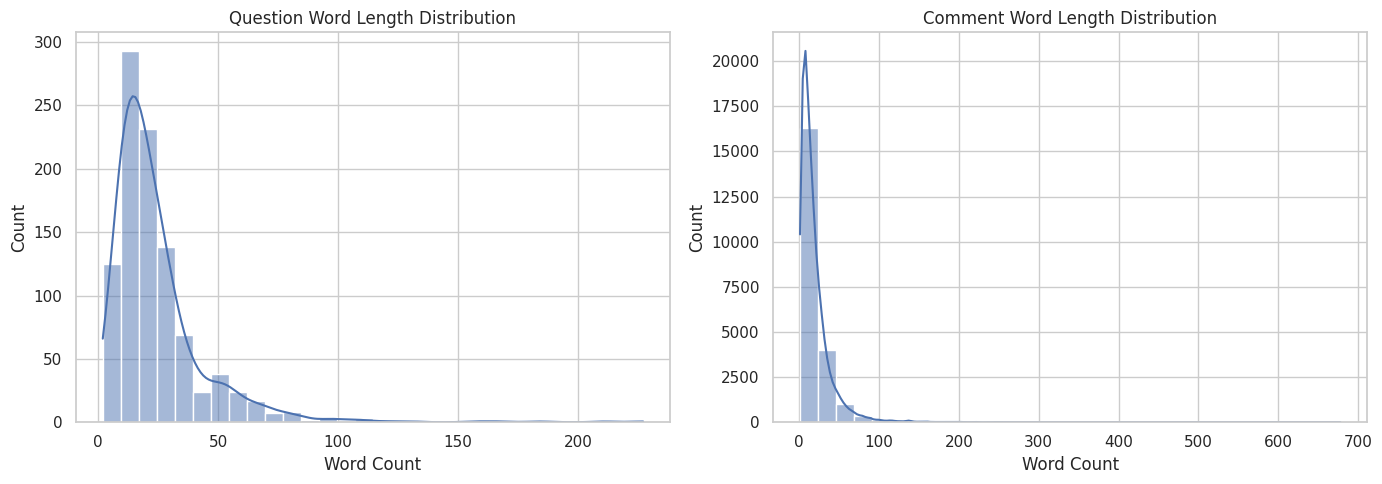

In [30]:
sns.set(style="whitegrid")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(question_word_len, bins=30, kde=True)
plt.title("Question Word Length Distribution")
plt.xlabel("Word Count")

plt.subplot(1, 2, 2)
sns.histplot(comment_word_lens, bins=30, kde=True)
plt.title("Comment Word Length Distribution")
plt.xlabel("Word Count")

plt.tight_layout()
plt.show()

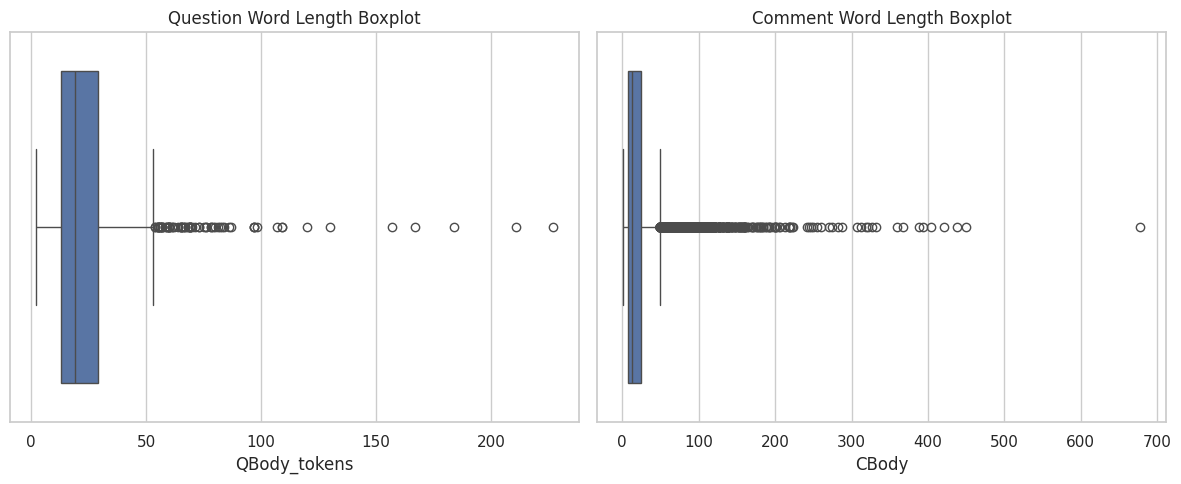

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=question_word_len)
plt.title("Question Word Length Boxplot")

plt.subplot(1, 2, 2)
sns.boxplot(x=comment_word_lens)
plt.title("Comment Word Length Boxplot")

plt.tight_layout()
plt.show()

## 6.2 Identify the Most Engaging Questions

In [32]:
answers_count = df_clean.apply(
    lambda row: {
        'QID': row['QID'],
        'count': len(row['Comments']),
        'QTYPE': row['QTYPE'],
    },
    axis=1
)
answers_count_df = pd.DataFrame(answers_count.tolist())
top_answers_count = answers_count_df.sort_values(by='count', ascending=False)

print("Top 10 Questions with the Most Answers:")
print(top_answers_count.head(10))

Top 10 Questions with the Most Answers:
         QID  count    QTYPE
571  1556257    315  General
152  1577970    313  General
342  1559359    215  General
728  1555428    215  General
194  1578477    166  General
969  1569562    144  General
256  1591164    143  General
628  1585904    137  General
677  1567278    137  General
8    1575297    136  General


In [33]:
type_analysis = (answers_count_df
                 .groupby('QTYPE')['count']
                 .agg(['count', 'mean', 'median'])
                 .sort_values(by='mean', ascending=False))

print("\nAverage and Median Answers by Category:")
print(type_analysis)


Average and Median Answers by Category:
         count       mean  median
QTYPE                            
General    990  22.208081    15.0


## 6.3 Analyze User Activity Patterns

- Determine peak hours and days when users are most active

In [34]:
comments_copy = comments.copy()

In [35]:
comments_copy['LabelDate_dt'] = pd.to_datetime(comments_copy['LabelDate'], errors='coerce')

In [36]:
comments_copy = comments_copy.dropna(subset=['LabelDate_dt']).copy()

comments_copy['Hour'] = comments_copy['LabelDate_dt'].dt.hour
comments_copy['Weekday'] = comments_copy['LabelDate_dt'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
comments_copy['Weekday'] = pd.Categorical(comments_copy['Weekday'], categories=weekday_order, ordered=True)

/tmp/ipython-input-37-1237508495.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=comments_copy, x='Hour', palette='Blues_d')


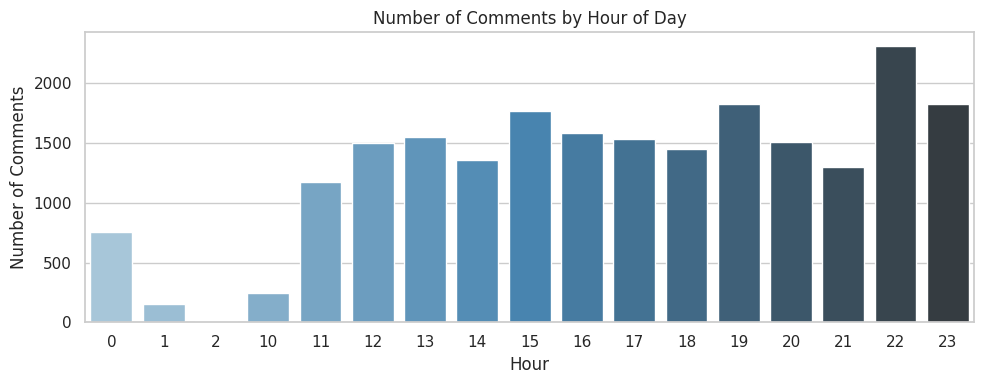

In [37]:
plt.figure(figsize=(10, 4))
sns.countplot(data=comments_copy, x='Hour', palette='Blues_d')
plt.title('Number of Comments by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

/tmp/ipython-input-38-2277103609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=comments_copy, x='Weekday', palette='Greens_d')


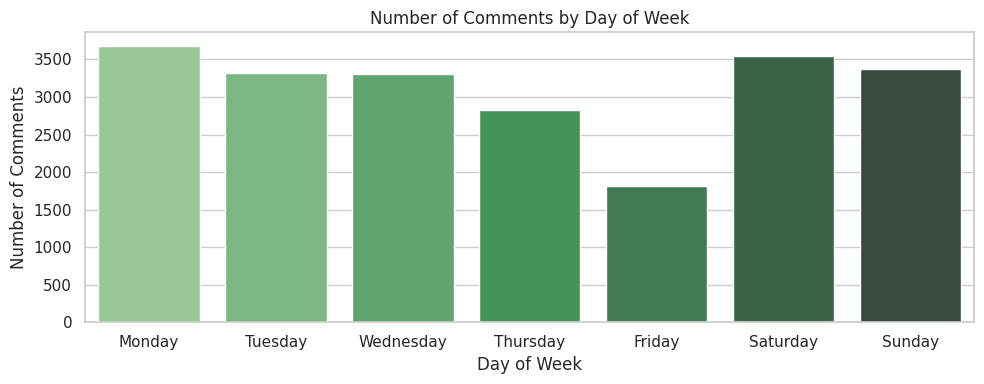

In [38]:
plt.figure(figsize=(10, 4))
sns.countplot(data=comments_copy, x='Weekday', palette='Greens_d')
plt.title('Number of Comments by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

/tmp/ipython-input-39-1679188490.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = comments_copy.pivot_table(


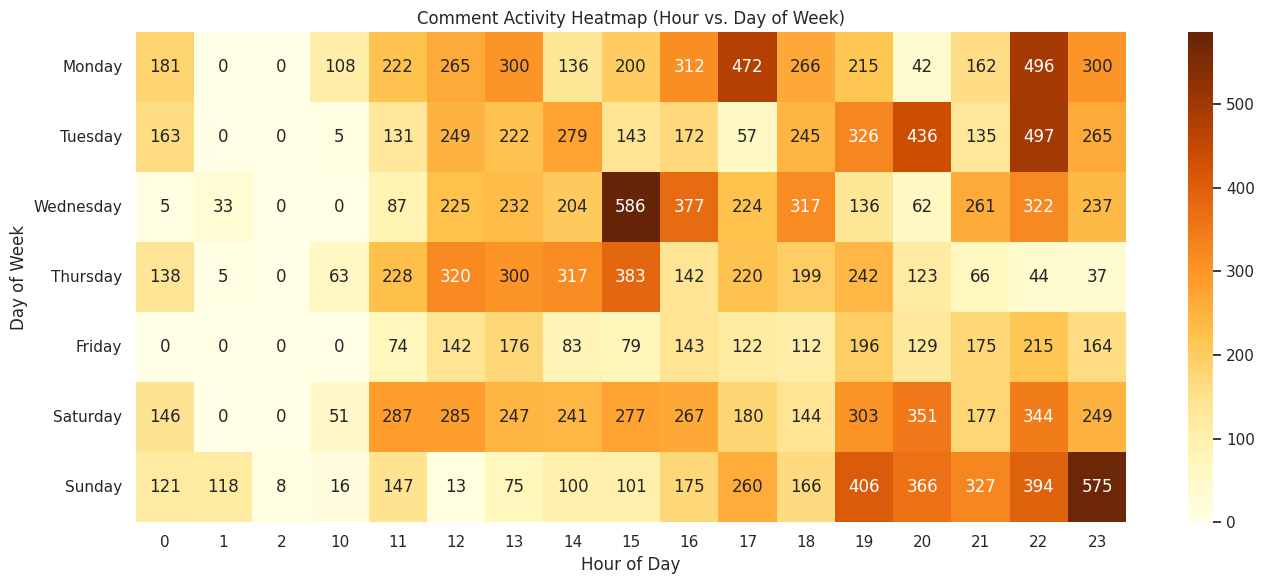

In [39]:
heatmap_data = comments_copy.pivot_table(
    index='Weekday',
    columns='Hour',
    values='CID',
    aggfunc='count'
).reindex(weekday_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrBr')
plt.title('Comment Activity Heatmap (Hour vs. Day of Week)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

## 6.4 Detect Top Answer Contributors

In [40]:
user_answer_counts = comments['CUsername'].value_counts()

print(f"\nTotal unique users: {len(user_answer_counts)}")
print(f"Total answers: {user_answer_counts.sum()}")


Total unique users: 6283
Total answers: 21986


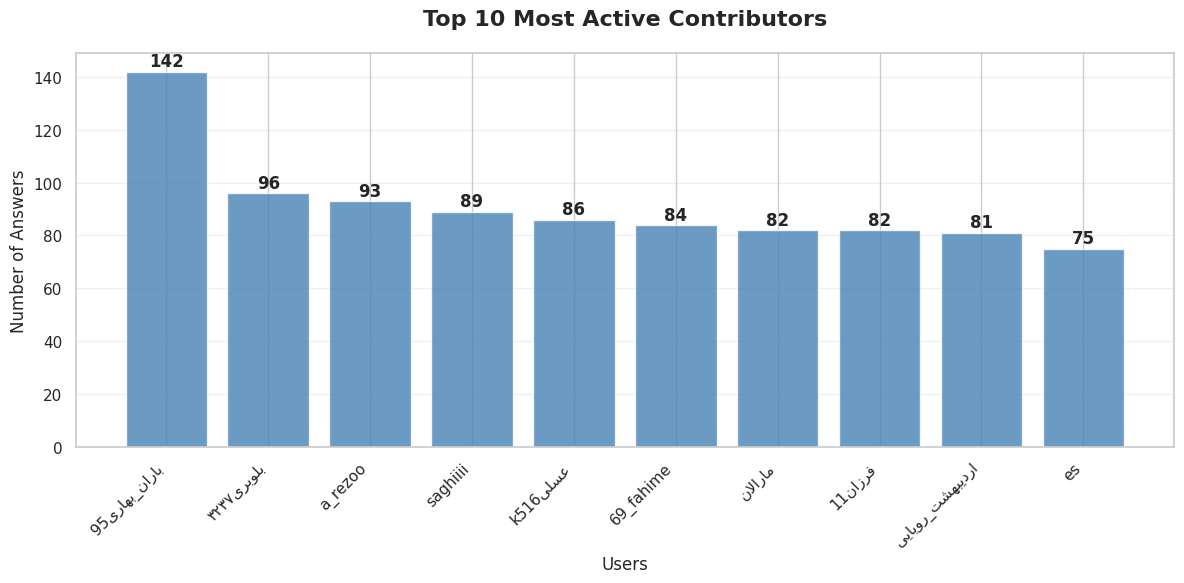

In [41]:
top_contributors = user_answer_counts.head(10)
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_contributors)), top_contributors.values,
               color='steelblue', alpha=0.8)
plt.title('Top 10 Most Active Contributors', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Users', fontsize=12)
plt.ylabel('Number of Answers', fontsize=12)

xtick_labels = [format_rtl_text(username) for username in top_contributors.index]
plt.xticks(range(len(top_contributors)), xtick_labels, rotation=45, ha='right')

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 6.5 Linguistic and word-level analysis

### 6.5.1 Word Frequency

In [42]:
question_tokens = df_clean['QBody_tokens'].explode()
question_tokens = question_tokens[question_tokens.str.match(r'^\w+$')]
question_word_counts = Counter(question_tokens)
question_freq_df = pd.DataFrame.from_dict(question_word_counts, orient='index', columns=['Frequency'])
question_freq_df = question_freq_df.sort_values(by='Frequency', ascending=False).reset_index()
question_freq_df.columns = ['Word', 'Frequency']

In [43]:
question_freq_df.head(10)

,Word,Frequency
0,هس,243
1,به,237
2,داره,214
3,یه,214
4,بچه,201
5,میشه,197
6,باشه,177
7,ال,176
8,پسر,165
9,چ,163


In [44]:
question_freq_df.tail(10)

,Word,Frequency
4479,مهریتو,1
4480,جرو,1
4481,اجرابر,1
4482,زند,1
4483,توء,1
4484,فاز,1
4485,بلاتکلیف,1
4486,دلشوره,1
4487,بارم,1
4488,ندیدند,1


In [45]:
comment_words = comments['CBodyClean'].dropna().apply(split_words).explode()
comment_words_cnt = Counter(comment_words)
comment_freq_df = pd.DataFrame.from_dict(comment_words_cnt, orient='index', columns=['Frequency'])
comment_freq_df = comment_freq_df.sort_values(by='Frequency', ascending=False).reset_index()
comment_freq_df.columns = ['Word', 'Frequency']

In [46]:
comment_freq_df.head(10)

,Word,Frequency
0,و,9689
1,که,5726
2,من,5481
3,از,5081
4,به,4979
5,هم,4107
6,رو,3934
7,خیلی,3260
8,تو,3218
9,با,3130


In [47]:
comment_freq_df.tail(10)

,Word,Frequency
30239,توست,1
30240,آرامشه,1
30241,اختلافاتى,1
30242,حرمتهایی,1
30243,هوات,1
30244,ارور,1
30245,هیچکاری,1
30246,ارزشى,1
30247,نزنى,1
30248,بازبینی,1


### 6.5.2 Word Cloud

In [48]:
def generate_wordcloud_from_df(df, title):
  word_freq_dict = dict(zip(df['Word'], df['Frequency']))

  wc = WordCloud(
      width=800,
      height=400,
      background_color='white',
      font_path=vazir_font.get_file(),
      colormap='viridis'
  ).generate_from_frequencies(word_freq_dict)

  plt.figure(figsize=(12, 6))
  plt.imshow(wc, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.tight_layout()
  plt.show()

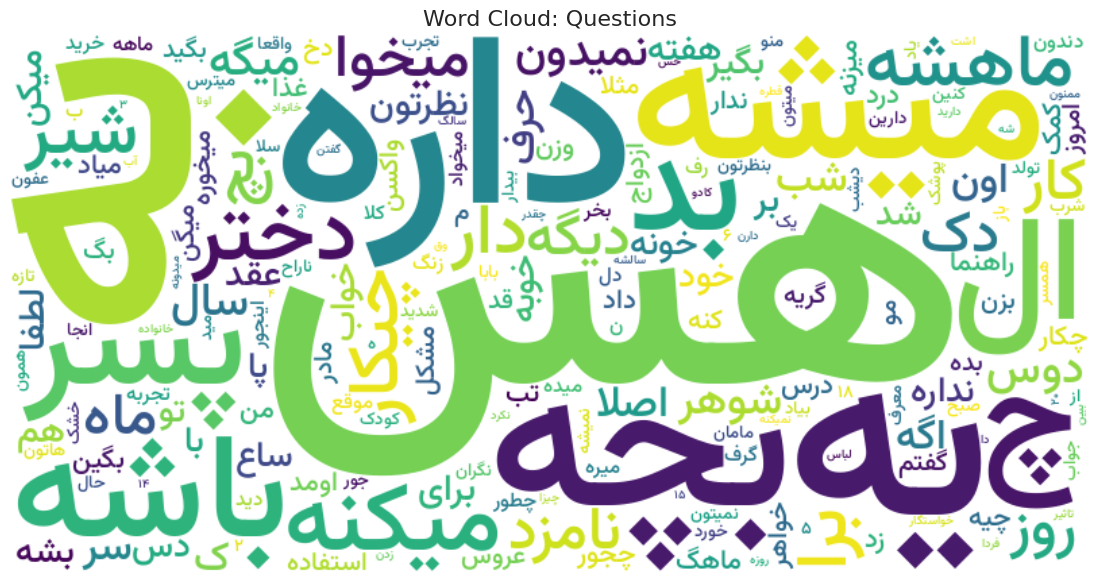

In [49]:
generate_wordcloud_from_df(question_freq_df, "Word Cloud: Questions")

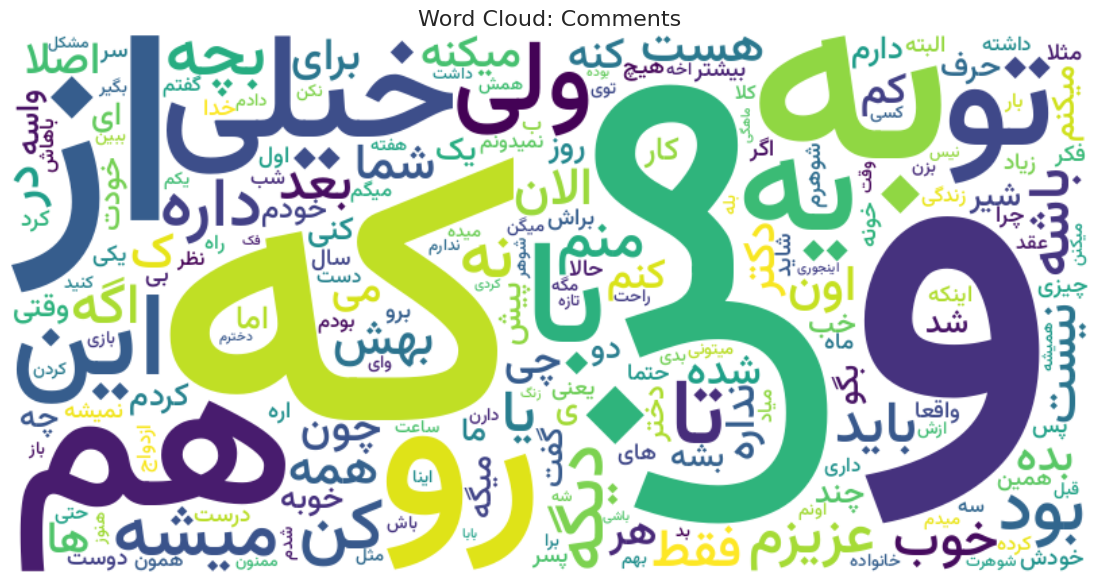

In [50]:
generate_wordcloud_from_df(comment_freq_df, "Word Cloud: Comments")

### 6.5.3 NGram

In [51]:
def extract_ngrams(tokens_list, n):
  ngrams = []
  for tokens in tokens_list:
    for i in range(len(tokens) - n + 1):
      ngram = ' '.join(tokens[i:i+n])
      ngrams.append(ngram)
  return ngrams

In [52]:
def plot_ngrams(tokens, n, top_n=10):
  ngrams = extract_ngrams(tokens, n)

  if not ngrams:
    print("No unigrams found")
    return

  ngrams_counts = Counter(ngrams)
  top_ngrams_counts = ngrams_counts.most_common(top_n)

  words, counts = zip(*top_ngrams_counts)

  words_fmt = [format_rtl_text(word) for word in words]

  plt.figure(figsize=(12, 8))
  plt.barh(range(len(words_fmt)), counts)
  plt.yticks(range(len(words_fmt)), words_fmt, fontproperties=vazir_font)
  plt.xlabel('Frequency')
  plt.title(f'Top {top_n} Unigrams')
  plt.gca().invert_yaxis()
  plt.tight_layout()
  plt.show()

In [53]:
pandarallel.initialize(progress_bar=True, nb_workers=2)

tokens_with_stopword = (
    df_clean['QBody']
    .dropna()
    .parallel_apply(lambda body: tokenization(clean_text(body)))
    .tolist()
)

INFO: Pandarallel will run on 2 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


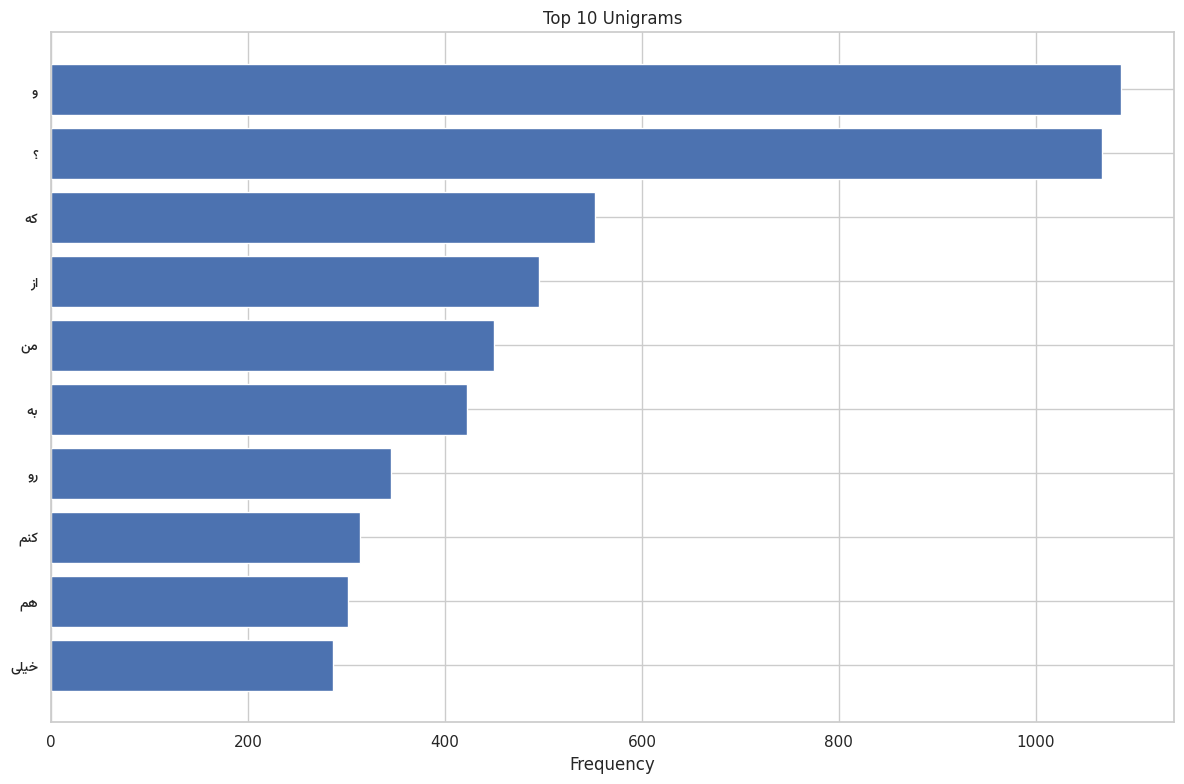

In [56]:
plot_ngrams(tokens_with_stopword, 1)

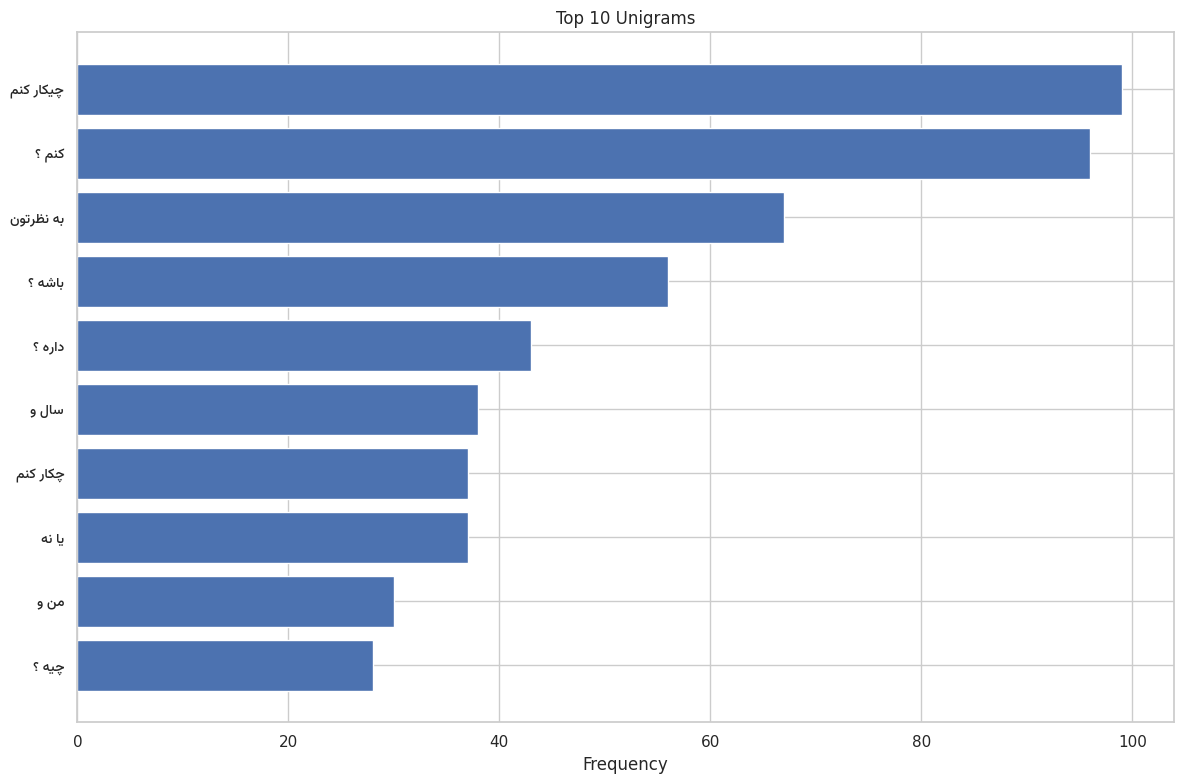

In [58]:
plot_ngrams(tokens_with_stopword, 2)

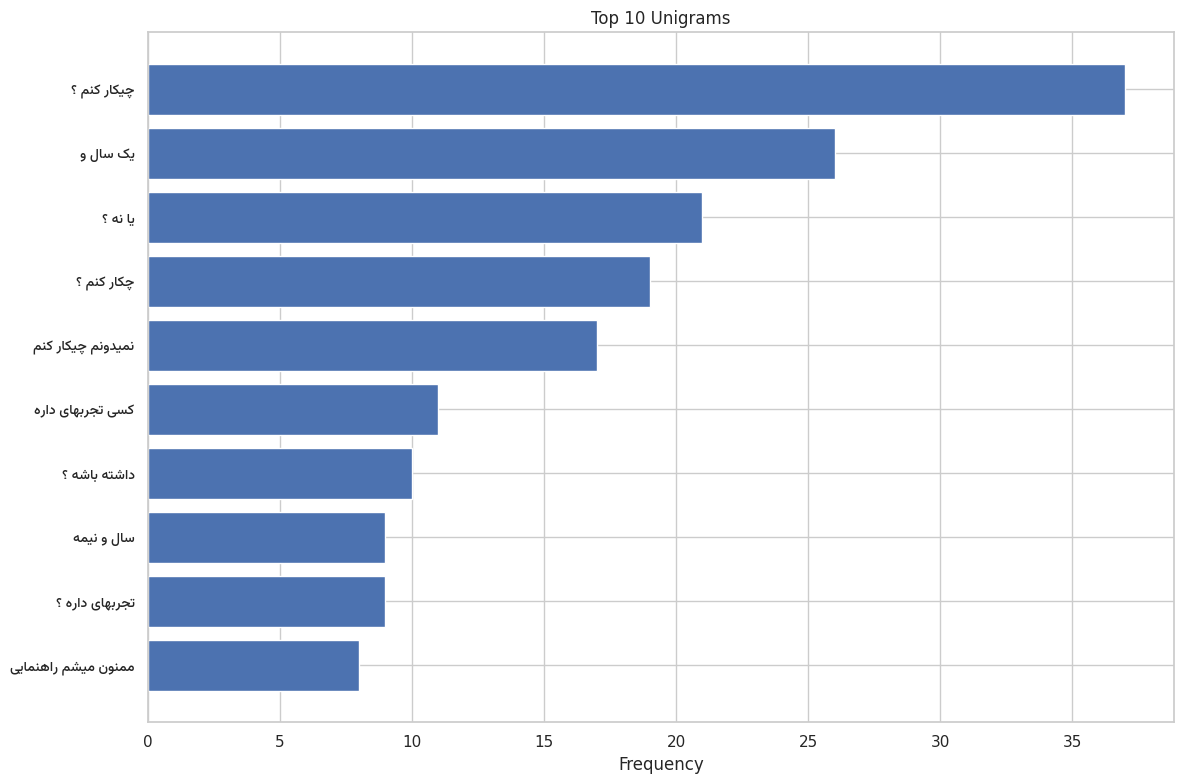

In [57]:
plot_ngrams(tokens_with_stopword, 3)

In [59]:
tokens_without_stopwords = df_clean['QBody_tokens'].tolist()

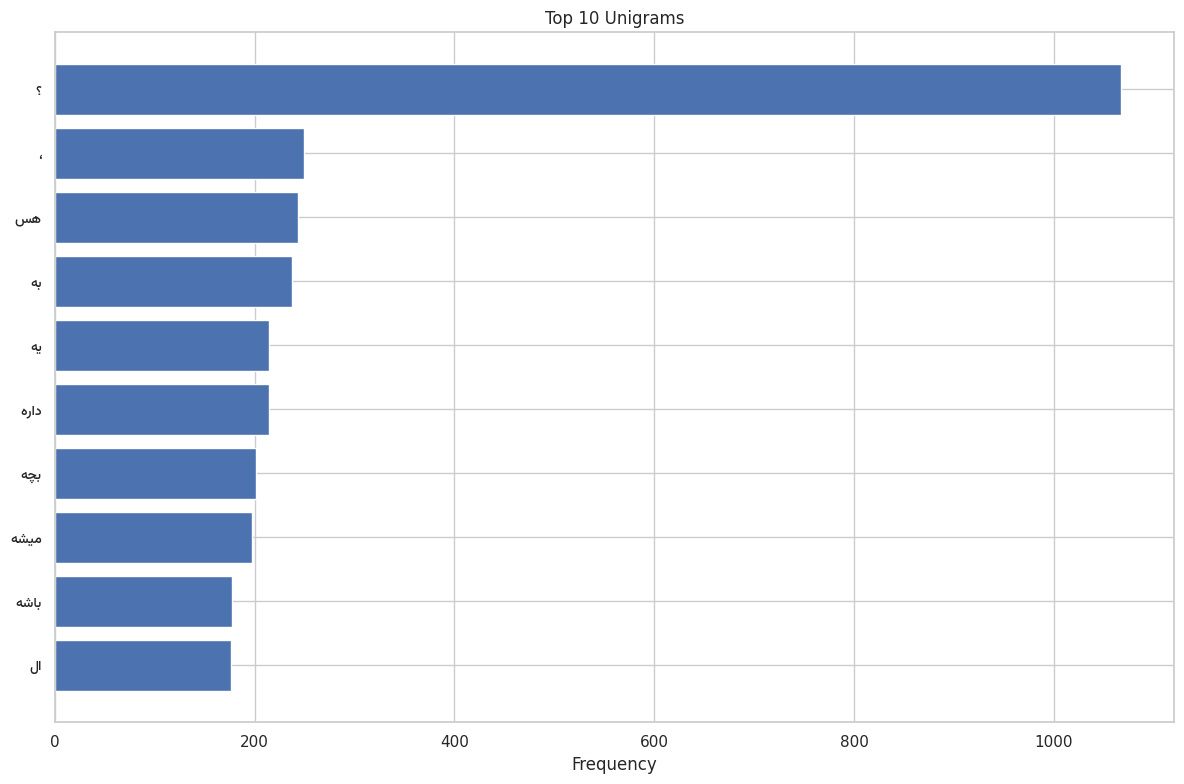

In [60]:
plot_ngrams(tokens_without_stopwords, 1)

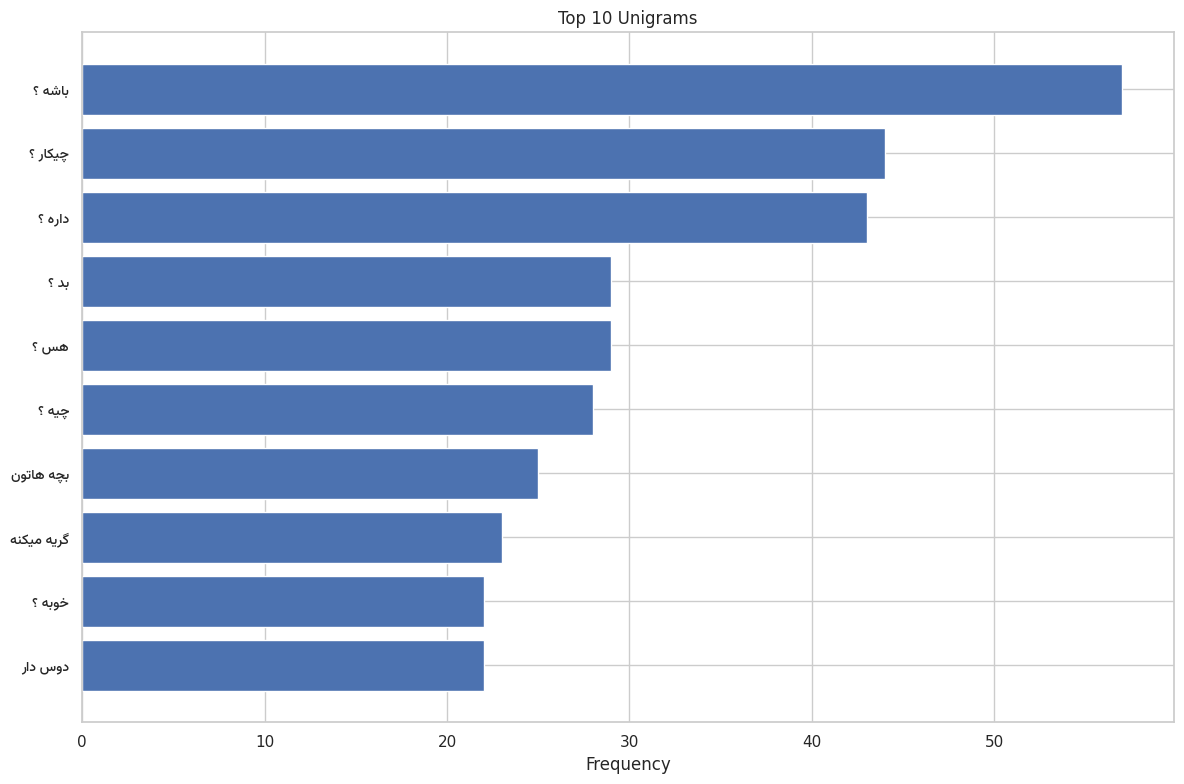

In [61]:
plot_ngrams(tokens_without_stopwords, 2)

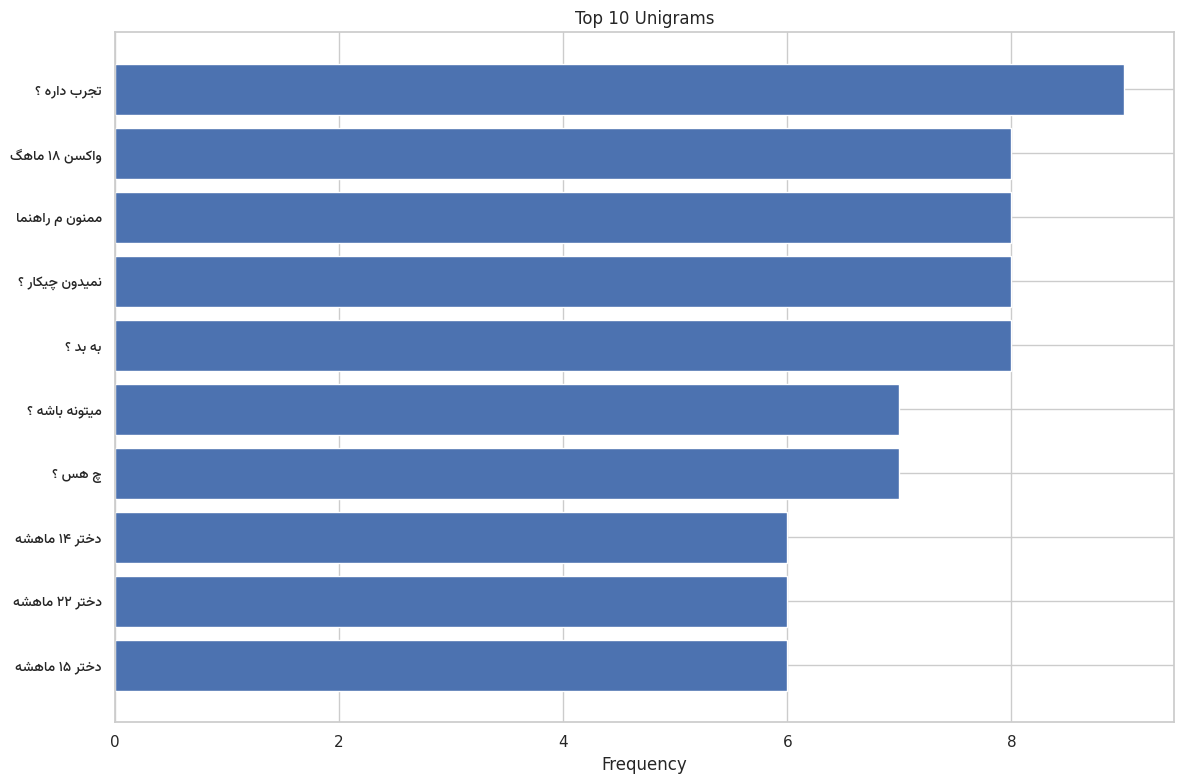

In [62]:
plot_ngrams(tokens_without_stopwords, 3)